# Setup

In [1]:
import pandas as pd
import pickle
import json
import os
import datetime as dt
from matplotlib import pyplot as plt

DATA_FOLDER = "H:/_DATA_ANALYSIS_FILES/"

# Raw Request Data

## Load

### Request Data

In [2]:
temp_request = pickle.load(open(os.path.join(DATA_FOLDER, "requestgroups_request.pkl"), "rb"))
print("Original columns:", temp_request.columns)
temp_request = temp_request[["id", "state", "created", "request_group_id"]].rename(columns={"id": "request_id"})
temp_request["created"] = pd.to_datetime(temp_request["created"], format="%Y-%m-%dT%H:%M:%S.%fZ")
temp_request

Original columns: Index(['id', 'observation_note', 'state', 'modified', 'created',
       'acceptability_threshold', 'request_group_id', 'extra_params',
       'configuration_repeats', 'optimization_type'],
      dtype='object')


,request_id,state,created,request_group_id
0,3053362,WINDOW_EXPIRED,2022-11-16 09:56:21.069,1581143
1,3097579,COMPLETED,2023-01-09 00:00:29.738,1615811
2,3057472,COMPLETED,2022-11-18 12:27:48.096,1582590
3,3112564,COMPLETED,2023-01-28 10:56:14.706,1628904
4,3112973,COMPLETED,2023-01-28 20:30:07.769,1629274
...,...,...,...,...
1062601,2327326,WINDOW_EXPIRED,2020-12-13 10:46:42.515,1107823
1062602,2327327,WINDOW_EXPIRED,2020-12-13 10:46:42.532,1107823
1062603,2327328,COMPLETED,2020-12-13 10:46:42.552,1107823
1062604,2327329,COMPLETED,2020-12-13 10:46:42.575,1107823


### RequestGroup Data

In [3]:
temp_group = pickle.load(open(os.path.join(DATA_FOLDER, "requestgroups_requestgroup.pkl"), "rb"))
print("Original columns:", temp_group.columns)
temp_group = temp_group[["id", "observation_type", "operator", "ipp_value", "proposal_id"]].rename(columns={"id": "request_group_id"})
temp_group

Original columns: Index(['id', 'name', 'observation_type', 'operator', 'ipp_value', 'created',
       'state', 'modified', 'proposal_id', 'submitter_id'],
      dtype='object')


,request_group_id,observation_type,operator,ipp_value,proposal_id
0,1381010,DIRECT,SINGLE,1.00,ASAS
1,1083530,DIRECT,SINGLE,1.00,calibrate
2,947053,NORMAL,SINGLE,1.05,auto_focus
3,1001499,DIRECT,SINGLE,1.00,auto_focus
4,1001493,DIRECT,SINGLE,1.00,auto_focus
...,...,...,...,...,...
691928,1232876,NORMAL,SINGLE,1.02,CON2021A-012
691929,1232875,NORMAL,SINGLE,1.02,CON2021A-012
691930,1232874,NORMAL,SINGLE,1.02,CON2021A-012
691931,1232873,NORMAL,SINGLE,1.02,CON2021A-012


### Location Data

In [4]:
temp_location = pickle.load(open(os.path.join(DATA_FOLDER, "requestgroups_location.pkl"), "rb")).drop(columns=["id"])
temp_location

,telescope_class,site,enclosure,telescope,request_id
0,1m0,,,,2048275
1,2m0,coj,,,2048300
2,0m4,,,,2048301
3,0m4,,,,2048302
4,1m0,,,,2048303
...,...,...,...,...,...
780965,0m4,,,,2934440
780966,0m4,,,,2934441
780967,0m4,,,,2934442
780968,0m4,,,,2934443


### Window Data

In [5]:
temp_window = pickle.load(open(os.path.join(DATA_FOLDER, "requestgroups_window.pkl"), "rb"))
temp_window["start"] = pd.to_datetime(temp_window["start"], format="%Y-%m-%dT%H:%M:%S.%fZ")
temp_window["end"] = pd.to_datetime(temp_window["end"], format="%Y-%m-%dT%H:%M:%S.%fZ")
temp_window

,id,start,end,request_id
0,1745990,2020-05-09 10:50:20.133,2020-05-09 22:50:20.133,2117945
1,1745992,2020-05-09 17:46:15.271,2020-05-09 18:46:15.271,2117947
2,1745994,2020-05-09 19:46:15.271,2020-05-09 20:46:15.271,2117949
3,1745996,2020-05-09 16:46:15.271,2020-05-09 17:46:15.271,2117951
4,1745998,2020-05-09 18:46:15.271,2020-05-09 19:46:15.271,2117953
...,...,...,...,...
786650,2405436,2022-09-05 21:15:16.000,2022-09-21 21:15:00.000,2993701
786651,2405437,2022-09-06 08:26:06.315,2022-09-07 08:26:06.315,2993702
786652,2405438,2022-08-31 15:30:00.000,2022-10-02 23:30:00.000,2993706
786653,2405439,2022-09-21 09:23:00.000,2022-09-21 09:29:00.000,2993707


In [6]:
def get_window_info(group):
    windows = []
    total_time = 0
    for r, row in group.iterrows():
        start = row["start"]
        end = row["end"]
        window_time = end - start
        total_time += window_time.days*60*60*24 + window_time.seconds
        windows.append([start, end])
    first_start = group["start"].min()
    last_end = group["end"].max()
    start_to_end = last_end - first_start
    start_to_end_time = start_to_end.days*60*60*24 + start_to_end.seconds
    return {
        "availability_windows": windows,
        "availability_sum": total_time, 
        "availability_span": start_to_end_time,
        "availability_start": first_start
    }

def single_window_info(row):
    windows = [row["start"], row["end"]]
    window_time = row["end"] - row["start"]
    total_time = window_time.days*60*60*24 + window_time.seconds
    return {
        "availability_windows": windows,
        "availability_sum": total_time,
        "availability_span": total_time,
        "availability_start": row["start"]
    }

window_data = {}
for request_id, group in temp_window.groupby("request_id"):
    if len(group) > 1:
        window_data[request_id] = get_window_info(group)
    else:
        window_data[request_id] = single_window_info(group.iloc[0])
windows = pd.DataFrame(window_data).transpose().reset_index().rename(columns={"index": "request_id"})
del window_data

windows

,request_id,availability_windows,availability_sum,availability_span,availability_start
0,2048275,"[2020-01-31 16:00:41, 2020-02-01 16:00:41]",86400,86400,2020-01-31 16:00:41.000
1,2048300,"[2020-02-01 10:02:16, 2020-02-01 18:32:32]",30616,30616,2020-02-01 10:02:16.000
2,2048301,"[2020-02-01 20:00:00, 2020-02-02 04:00:00]",28800,28800,2020-02-01 20:00:00.000
3,2048302,"[2020-02-02 04:00:00, 2020-02-02 12:00:00]",28800,28800,2020-02-02 04:00:00.000
4,2048303,"[2020-02-01 01:50:04.018000, 2020-02-02 01:50:...",86400,86400,2020-02-01 01:50:04.018
...,...,...,...,...,...
780965,3117669,"[2023-02-01 06:41:25, 2023-02-02 06:41:25]",86400,86400,2023-02-01 06:41:25.000
780966,3117670,"[2023-02-01 06:41:27, 2023-02-02 06:41:27]",86400,86400,2023-02-01 06:41:27.000
780967,3117671,"[2023-02-01 06:41:28, 2023-02-02 06:41:28]",86400,86400,2023-02-01 06:41:28.000
780968,3117672,"[2023-02-01 06:41:29, 2023-02-02 06:41:29]",86400,86400,2023-02-01 06:41:29.000


### Configurations

In [7]:
config_data_list = []
for i in range(2):
    temp = pickle.load(open(os.path.join(DATA_FOLDER, f"requestgroups_configuration_{i}.pkl"), "rb"))
    expose_types = temp.groupby("request_id")["type"].unique().to_frame().reset_index()
    instruments = temp.groupby("request_id")["instrument_type"].unique().to_frame().reset_index()
    merged = expose_types.merge(instruments, how="left", on="request_id")
    config_data_list.append(merged)
temp_configs = pd.concat(config_data_list)
del config_data_list

temp_configs["type"] = temp_configs["type"].apply(lambda x: tuple(sorted(x)))
temp_configs["instrument_type"] = temp_configs["instrument_type"].apply(lambda x: tuple(sorted(x)))

temp_configs

,request_id,type,instrument_type
0,2048275,"(EXPOSE,)","(1M0-SCICAM-SINISTRO,)"
1,2048276,"(BIAS, DARK)","(0M4-SCICAM-SBIG,)"
2,2048277,"(BIAS, DARK)","(0M4-SCICAM-SBIG,)"
3,2048278,"(SKY_FLAT,)","(0M4-SCICAM-SBIG,)"
4,2048279,"(SKY_FLAT,)","(0M4-SCICAM-SBIG,)"
...,...,...,...
504871,3108901,"(REPEAT_EXPOSE,)","(2M0-SCICAM-MUSCAT,)"
504872,3108902,"(REPEAT_EXPOSE,)","(2M0-SCICAM-MUSCAT,)"
504873,3108903,"(REPEAT_EXPOSE,)","(2M0-SCICAM-MUSCAT,)"
504874,3108904,"(REPEAT_EXPOSE,)","(0M4-SCICAM-QHY600,)"


## Merge

In [8]:
requests_full = temp_request.merge(
                    temp_group, how="left", on="request_group_id"
                ).merge(
                    temp_location, how="left", on="request_id"
                ).merge(
                    windows, how="left", on="request_id"
                ).merge(
                    temp_configs, how="left", on="request_id"
                )

del temp_request
del temp_group
del temp_location
del windows
del temp_configs

requests_full

,request_id,state,created,request_group_id,observation_type,operator,ipp_value,proposal_id,telescope_class,site,enclosure,telescope,availability_windows,availability_sum,availability_span,availability_start,type,instrument_type
0,3053362,WINDOW_EXPIRED,2022-11-16 09:56:21.069,1581143,NORMAL,MANY,1.05,KEY2020B-007,0m4,,,,"[2023-01-08 07:48:10, 2023-01-08 11:48:10]",14400,14400,2023-01-08 07:48:10.000,"(EXPOSE,)","(0M4-SCICAM-SBIG,)"
1,3097579,COMPLETED,2023-01-09 00:00:29.738,1615811,NORMAL,MANY,1.05,SAAO2022B-003,1m0,,,,"[2023-01-28 02:50:06, 2023-01-28 03:09:54]",1188,1188,2023-01-28 02:50:06.000,"(EXPOSE,)","(1M0-SCICAM-SINISTRO,)"
2,3057472,COMPLETED,2022-11-18 12:27:48.096,1582590,NORMAL,MANY,1.05,KEY2020B-007,0m4,,,,"[2023-01-28 22:10:21, 2023-01-29 02:10:21]",14400,14400,2023-01-28 22:10:21.000,"(EXPOSE,)","(0M4-SCICAM-SBIG,)"
3,3112564,COMPLETED,2023-01-28 10:56:14.706,1628904,NORMAL,SINGLE,1.00,KEY2020B-006,1m0,,,,"[2023-01-28 10:58:13, 2023-01-29 10:58:13]",86400,86400,2023-01-28 10:58:13.000,"(EXPOSE,)","(1M0-SCICAM-SINISTRO,)"
4,3112973,COMPLETED,2023-01-28 20:30:07.769,1629274,NORMAL,SINGLE,1.10,KEY2020B-002,1m0,,,,"[2023-01-28 20:30:06.280000, 2023-01-29 02:30:...",21600,21600,2023-01-28 20:30:06.280,"(EXPOSE,)","(1M0-SCICAM-SINISTRO,)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062607,2327326,WINDOW_EXPIRED,2020-12-13 10:46:42.515,1107823,NORMAL,MANY,1.00,KEY2020B-007,0m4,,,,"[2021-01-20 14:33:55, 2021-01-20 18:33:55]",14400,14400,2021-01-20 14:33:55.000,"(EXPOSE,)","(0M4-SCICAM-SBIG,)"
1062608,2327327,WINDOW_EXPIRED,2020-12-13 10:46:42.532,1107823,NORMAL,MANY,1.00,KEY2020B-007,0m4,,,,"[2021-01-20 20:33:55, 2021-01-21 00:33:55]",14400,14400,2021-01-20 20:33:55.000,"(EXPOSE,)","(0M4-SCICAM-SBIG,)"
1062609,2327328,COMPLETED,2020-12-13 10:46:42.552,1107823,NORMAL,MANY,1.00,KEY2020B-007,0m4,,,,"[2021-01-21 02:33:55, 2021-01-21 06:33:55]",14400,14400,2021-01-21 02:33:55.000,"(EXPOSE,)","(0M4-SCICAM-SBIG,)"
1062610,2327329,COMPLETED,2020-12-13 10:46:42.575,1107823,NORMAL,MANY,1.00,KEY2020B-007,0m4,,,,"[2021-01-21 08:33:55, 2021-01-21 12:33:55]",14400,14400,2021-01-21 08:33:55.000,"(EXPOSE,)","(0M4-SCICAM-SBIG,)"


In [9]:
requests_full[requests_full["observation_type"]=="DIRECT"]

,request_id,state,created,request_group_id,observation_type,operator,ipp_value,proposal_id,telescope_class,site,enclosure,telescope,availability_windows,availability_sum,availability_span,availability_start,type,instrument_type
6,3097037,WINDOW_EXPIRED,2023-01-08 10:11:58.573,1615446,DIRECT,SINGLE,1.0,ASAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,"(EXPOSE,)","(0M4-SCICAM-FLI,)"
7,2812759,WINDOW_EXPIRED,2022-03-13 18:21:05.112,1412924,DIRECT,SINGLE,1.0,ASAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,"(EXPOSE,)","(0M4-SCICAM-FLI,)"
8,2812749,WINDOW_EXPIRED,2022-03-13 18:18:46.845,1412914,DIRECT,SINGLE,1.0,ASAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,"(EXPOSE,)","(0M4-SCICAM-FLI,)"
11,3113424,COMPLETED,2023-01-29 15:05:53.071,1629668,DIRECT,SINGLE,1.0,calibrate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,"(BIAS, DARK)","(0M4-SCICAM-SBIG,)"
12,3113420,COMPLETED,2023-01-29 15:05:52.022,1629664,DIRECT,SINGLE,1.0,calibrate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,"(BIAS, DARK)","(0M4-SCICAM-SBIG,)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062309,2360757,WINDOW_EXPIRED,2021-01-19 07:05:17.121,1132422,DIRECT,SINGLE,1.0,calibrate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,"(SKY_FLAT,)","(1M0-SCICAM-SINISTRO,)"
1062310,2361214,WINDOW_EXPIRED,2021-01-19 17:05:25.934,1132735,DIRECT,SINGLE,1.0,auto_focus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,"(AUTO_FOCUS,)","(1M0-SCICAM-SINISTRO,)"
1062401,2359849,WINDOW_EXPIRED,2021-01-18 07:07:32.465,1131664,DIRECT,SINGLE,1.0,ASAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,"(EXPOSE,)","(0M4-SCICAM-FLI,)"
1062408,2360940,WINDOW_EXPIRED,2021-01-19 11:05:15.361,1132507,DIRECT,SINGLE,1.0,calibrate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,"(SKY_FLAT,)","(0M4-SCICAM-SBIG,)"


## Filter

### Observation_Type

* DIRECT requests are apparently ones that have been manually scheduled on a telescope, and not gone through the scheduler?
* All DIRECT requests are lacking Availability Windows and Targets (I think, on the Targets).
* Non-DIRECT requests do not lack Availability Windows.

For this analysis, we are only interested in NORMAL requests, as everything else functions slightly differently. I'll check with Rachel whether it's worth including the other types, but I think this works for now.

<BarContainer object of 4 artists>

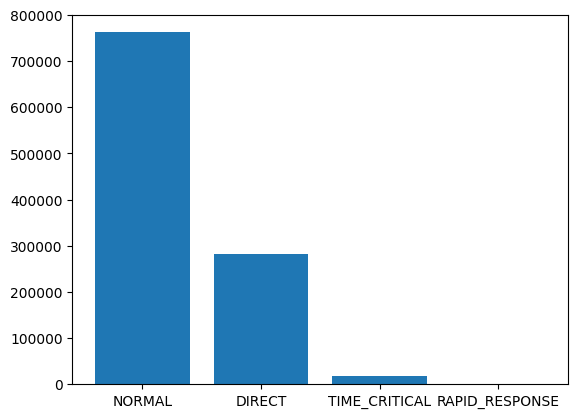

In [10]:
obs_type_data = requests_full["observation_type"].value_counts().to_dict()
plt.bar(obs_type_data.keys(), obs_type_data.values())

In [11]:
print("DIRECT Requests:", len(requests_full[requests_full["observation_type"]=="DIRECT"]))
print("DIRECT Requests without Availability Windows:", requests_full[requests_full["observation_type"]=="DIRECT"]["availability_windows"].isna().sum())
print("Non-DIRECT Requests without Availability Windows:", requests_full[requests_full["observation_type"]!="DIRECT"]["availability_windows"].isna().sum())

DIRECT Requests: 281642
DIRECT Requests without Availability Windows: 281642
Non-DIRECT Requests without Availability Windows: 0


In [12]:
valid = requests_full[requests_full["observation_type"]=="NORMAL"]
print("Valid Requests:", len(valid))

Valid Requests: 762310


### Location

In [13]:
valid["telescope_class"].value_counts()

telescope_class
1m0    441583
0m4    245319
2m0     73124
4m0      2284
Name: count, dtype: int64

In [14]:
valid_12 = valid[valid["telescope_class"].isin(["1m0", "2m0"])]
print("1m and 2m Requests:", len(valid_12))

1m and 2m Requests: 514707


## Get Valid Proposal IDs

In [15]:
used_proposals = valid_12["proposal_id"].unique()

# Condensed Request Data

In [16]:
condensed_dfs = []

condensed_2m = pd.read_pickle("H:/_DATA_ANALYSIS_FILES/2m_large_all.pkldf")[["id", "windows", "valid_telescopes", "total_duration"]]
condensed_dfs.append(condensed_2m)

for i in range(10):
    print(f"\r{i}", end="")
    temp_condensed_1m = pd.read_pickle(f"H:/_DATA_ANALYSIS_FILES/1m_condensed_{i}.pkldf")[["id", "windows", "valid_telescopes", "total_duration"]]
    condensed_dfs.append(temp_condensed_1m)
print("\r \r", end="")

condensed = pd.concat(condensed_dfs)
valid_12 = valid_12.merge(condensed, how="left", left_on="request_id", right_on="id")

valid_12

,request_id,state,created,request_group_id,observation_type,operator,ipp_value,proposal_id,telescope_class,site,...,availability_windows,availability_sum,availability_span,availability_start,type,instrument_type,id,windows,valid_telescopes,total_duration
0,3097579,COMPLETED,2023-01-09 00:00:29.738,1615811,NORMAL,MANY,1.05,SAAO2022B-003,1m0,,...,"[2023-01-28 02:50:06, 2023-01-28 03:09:54]",1188,1188,2023-01-28 02:50:06.000,"(EXPOSE,)","(1M0-SCICAM-SINISTRO,)",3097579,{'1m0a.doma.lsc': Timestamp('2023-01-28 02:50:...,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",271
1,3112564,COMPLETED,2023-01-28 10:56:14.706,1628904,NORMAL,SINGLE,1.00,KEY2020B-006,1m0,,...,"[2023-01-28 10:58:13, 2023-01-29 10:58:13]",86400,86400,2023-01-28 10:58:13.000,"(EXPOSE,)","(1M0-SCICAM-SINISTRO,)",3112564,{'1m0a.doma.lsc': Timestamp('2023-01-29 00:41:...,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",2226
2,3112973,COMPLETED,2023-01-28 20:30:07.769,1629274,NORMAL,SINGLE,1.10,KEY2020B-002,1m0,,...,"[2023-01-28 20:30:06.280000, 2023-01-29 02:30:...",21600,21600,2023-01-28 20:30:06.280,"(EXPOSE,)","(1M0-SCICAM-SINISTRO,)",3112973,{'1m0a.doma.lsc': Timestamp('2023-01-29 00:41:...,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",2666
3,3097636,COMPLETED,2023-01-09 00:07:13.421,1615821,NORMAL,MANY,1.05,SAAO2022B-003,1m0,,...,"[2023-01-28 18:05:46, 2023-01-29 06:05:46]",43200,43200,2023-01-28 18:05:46.000,"(EXPOSE,)","(1M0-SCICAM-SINISTRO,)",3097636,{'1m0a.doma.lsc': Timestamp('2023-01-29 01:29:...,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",271
4,2816102,COMPLETED,2022-03-16 22:10:07.637,1414793,NORMAL,SINGLE,1.01,KEY2020B-002,1m0,,...,"[2022-03-16 22:10:06.327000, 2022-03-17 22:10:...",86400,86400,2022-03-16 22:10:06.327,"(EXPOSE,)","(1M0-SCICAM-SINISTRO,)",2816102,{'1m0a.doma.lsc': Timestamp('2022-03-16 23:50:...,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",1506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
514702,2327171,WINDOW_EXPIRED,2020-12-13 10:40:37.960,1107821,NORMAL,SINGLE,1.00,NOAO2020B-011,1m0,,...,"[2020-12-13 02:40:37, 2020-12-14 02:40:37]",86400,86400,2020-12-13 02:40:37.000,"(EXPOSE,)","(1M0-SCICAM-SINISTRO,)",2327171,{'1m0a.doma.lsc': Timestamp('2020-12-13 07:48:...,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",720
514703,2327168,WINDOW_EXPIRED,2020-12-13 10:20:08.025,1107818,NORMAL,SINGLE,1.00,TAU2020B-017,1m0,,...,"[2020-12-13 10:20:05.498000, 2020-12-14 10:20:...",86400,86400,2020-12-13 10:20:05.498,"(EXPOSE,)","(1M0-SCICAM-SINISTRO,)",2327168,{'1m0a.domb.elp': Timestamp('2020-12-14 00:52:...,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",1990
514704,2359397,COMPLETED,2021-01-17 17:40:52.817,1131247,NORMAL,SINGLE,1.00,NOAO2020B-011,1m0,,...,"[2021-01-17 09:40:51, 2021-01-18 09:40:51]",86400,86400,2021-01-17 09:40:51.000,"(EXPOSE,)","(1M0-SCICAM-SINISTRO,)",2359397,{'1m0a.doma.lsc': Timestamp('2021-01-18 05:26:...,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",872
514705,2359738,WINDOW_EXPIRED,2021-01-18 02:00:40.082,1131558,NORMAL,SINGLE,1.05,auto_focus,1m0,coj,...,"[2021-01-18 17:10:30.791000, 2021-01-18 18:10:...",3600,3600,2021-01-18 17:10:30.791,"(AUTO_FOCUS,)","(1M0-SCICAM-SINISTRO,)",2359738,{'1m0a.domb.coj': Timestamp('2021-01-18 17:10:...,[1m0a.domb.coj],542


In [25]:
valid_12[valid_12["total_duration"].isna()]["telescope_class"].value_counts()

telescope_class
2m0    1744
Name: count, dtype: int64

## WIP - Recompute data for missing condensed requests

In [18]:
valid_12[valid_12["total_duration"].isna()]

,request_id,state,created,request_group_id,observation_type,operator,ipp_value,proposal_id,telescope_class,site,...,availability_windows,availability_sum,availability_span,availability_start,type,instrument_type,id,windows,valid_telescopes,total_duration
385,2049085,WINDOW_EXPIRED,2020-02-02 13:59:14.549,933462,NORMAL,MANY,1.05,LCO2020A-001,2m0,,...,"[2020-02-03 11:18:45, 2020-02-03 12:00:00]",2475,2475,2020-02-03 11:18:45,"(EXPOSE,)","(2M0-SCICAM-SPECTRAL,)",NaN,NaN,NaN,NaN
386,2049086,WINDOW_EXPIRED,2020-02-02 13:59:14.560,933462,NORMAL,MANY,1.05,LCO2020A-001,2m0,,...,"[2020-02-03 16:10:00, 2020-02-03 16:40:00]",1800,1800,2020-02-03 16:10:00,"(EXPOSE,)","(2M0-SCICAM-SPECTRAL,)",NaN,NaN,NaN,NaN
388,2049087,WINDOW_EXPIRED,2020-02-02 13:59:14.571,933462,NORMAL,MANY,1.05,LCO2020A-001,2m0,,...,"[2020-02-03 16:40:00, 2020-02-03 17:18:45]",2325,2325,2020-02-03 16:40:00,"(EXPOSE,)","(2M0-SCICAM-SPECTRAL,)",NaN,NaN,NaN,NaN
389,2049088,WINDOW_EXPIRED,2020-02-02 13:59:14.582,933462,NORMAL,MANY,1.05,LCO2020A-001,2m0,,...,"[2020-02-03 17:18:45, 2020-02-03 17:50:00]",1875,1875,2020-02-03 17:18:45,"(EXPOSE,)","(2M0-SCICAM-SPECTRAL,)",NaN,NaN,NaN,NaN
390,2049090,WINDOW_EXPIRED,2020-02-02 13:59:14.606,933462,NORMAL,MANY,1.05,LCO2020A-001,2m0,,...,"[2020-02-04 12:18:45, 2020-02-04 13:18:45]",3600,3600,2020-02-04 12:18:45,"(EXPOSE,)","(2M0-SCICAM-SPECTRAL,)",NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
509143,2304315,COMPLETED,2020-11-25 06:16:29.431,1095881,NORMAL,SINGLE,1.10,LCO2020B-006,2m0,ogg,...,"[2020-11-25 11:58:00, 2020-11-25 15:28:00]",12600,12600,2020-11-25 11:58:00,"(REPEAT_EXPOSE,)","(2M0-SCICAM-MUSCAT,)",NaN,NaN,NaN,NaN
510179,2306463,COMPLETED,2020-11-28 01:51:52.113,1097554,NORMAL,SINGLE,0.95,HAW2020B-002,2m0,,...,"[2020-11-27 22:45:00, 2020-12-03 22:45:00]",518400,518400,2020-11-27 22:45:00,"(EXPOSE,)","(2M0-SCICAM-MUSCAT,)",NaN,NaN,NaN,NaN
512047,2311221,COMPLETED,2020-12-02 00:31:43.770,1100017,NORMAL,SINGLE,1.05,NOAO2020B-007,2m0,,...,"[2020-12-02 00:26:04, 2020-12-03 00:26:04]",86400,86400,2020-12-02 00:26:04,"(EXPOSE,)","(2M0-SCICAM-MUSCAT,)",NaN,NaN,NaN,NaN
512971,2314513,COMPLETED,2020-12-03 21:57:09.888,1101206,NORMAL,SINGLE,1.05,NOAO2020B-007,2m0,,...,"[2020-12-03 21:53:30, 2020-12-04 21:53:30]",86400,86400,2020-12-03 21:53:30,"(EXPOSE,)","(2M0-SCICAM-SPECTRAL,)",NaN,NaN,NaN,NaN


In [53]:
valid_12[valid_12["request_id"]==2561624]

,request_id,state,created,request_group_id,observation_type,operator,ipp_value,proposal_id,telescope_class,site,...,id,windows,valid_telescopes,total_duration,semester_start,semester_position,weekday,week,date,year
140574,2561624,WINDOW_EXPIRED,2021-06-27 13:02:57.306,1245357,NORMAL,SINGLE,1.0,CON2021A-011,2m0,,...,NaN,NaN,NaN,NaN,2021-02-01,"(2021-02-01 00:00:00, 146)",6,25,2021-06-27,2021


In [28]:
invalid_request_ids = valid_12[valid_12["total_duration"].isna()]["request_id"].to_list()

In [29]:
json.dump(invalid_request_ids, open("invalid_request_ids.json", "w"))

In [27]:
valid_12[valid_12["total_duration"].isna()]["state"].value_counts()

state
WINDOW_EXPIRED    1184
COMPLETED          487
CANCELED            73
Name: count, dtype: int64

In [31]:
valid_12[valid_12["total_duration"].isna()]["telescope_class"].value_counts()

telescope_class
2m0    1744
Name: count, dtype: int64

In [19]:
# data = pickle.load(open(os.path.join(DATA_FOLDER, "requestgroups_configuration_0.pkl"), "rb"))

In [20]:
# data

In [21]:
# data[data["request_id"]==2056300]

# Proposal Data

In [22]:
temp_proposals = pickle.load(open(os.path.join(DATA_FOLDER, "proposals_proposal.pkl"), "rb"))
print("Original columns:", temp_proposals.columns)
temp_proposals = temp_proposals[temp_proposals["id"].isin(used_proposals)]
temp_proposals = temp_proposals[["id", "tac_priority", "non_science", "direct_submission"]].rename(columns={"id": "proposal_id"})

proposal_requests = valid_12["proposal_id"].value_counts().to_frame().rename(columns={"count": "proposal_requests"}).reset_index()
proposal_groups = valid_12[["proposal_id", "request_group_id"]].value_counts().to_frame().reset_index()["proposal_id"].value_counts().to_frame().reset_index().rename(columns={"count": "proposal_groups"})

proposals = temp_proposals.merge(proposal_groups, on="proposal_id").merge(proposal_requests, on="proposal_id")

proposals

Original columns: Index(['id', 'active', 'title', 'abstract', 'tac_priority', 'tac_rank',
       'public', 'non_science', 'direct_submission', 'sca_id', 'tags'],
      dtype='object')


,proposal_id,tac_priority,non_science,direct_submission,proposal_groups,proposal_requests
0,LCO2021A-101,22,False,False,10,285
1,CON2021A-012,25,False,False,2868,2900
2,DDT2020A-007,20,False,False,9,9
3,TAU2022A-006,21,False,False,3,3
4,ANU2022A-002,28,False,False,76,771
...,...,...,...,...,...,...
576,IAC2023A-007,13,False,False,1,1
577,NSF2023A-011,20,False,False,462,462
578,NSF2023A-025,11,False,False,2,2
579,SUPA2023A-005,21,False,False,2,2


## Get Calibration Proposal IDs

In [23]:
extra_calibration_proposals = [
    "MuSCAT Commissioning",
    "calibrate",
    "DeltaRho Commissioning",
    "TOM demo scheduler"
]

high_priority_proposals = [
    "LCO2020B-011",
    "DDT2021B-004",
    "NSF2022A-009"
]

calibration_proposal_ids = temp_proposals[temp_proposals["non_science"]==True]["proposal_id"].to_list()
calibration_proposal_ids += extra_calibration_proposals
print(calibration_proposal_ids)

temp_proposals[(temp_proposals["non_science"]==False)&(temp_proposals["tac_priority"]>30)]

['OGG_calib', 'standard', 'LCOSchedulerTest', 'auto_focus', 'LCOEngineering', 'urgent_auto_focus', 'ENG2017AB-001', 'COJ_calib', 'FLOYDS standards', 'NRES standards', 'rescue_auto_focus', 'Photometric standards', 'MuSCAT Commissioning', 'calibrate', 'DeltaRho Commissioning', 'TOM demo scheduler']


,proposal_id,tac_priority,non_science,direct_submission
97,MuSCAT Commissioning,40,False,False
273,DDT2020B-006,33,False,False
1060,LCO2020B-011,200,False,False
2149,DDT2021A-011,33,False,False
2291,NSF2022A-009,10000,False,False
2305,LCO2022B-006,40,False,True
2508,KEY2020B-002,35,False,False


# Compute Additional Values

In [24]:
def find_semester_start(dt_date):
    semester_starts = [
        dt.datetime(2020, 2, 1),
        dt.datetime(2020, 8, 1),
        dt.datetime(2021, 2, 1),
        dt.datetime(2021, 8, 1),
        dt.datetime(2022, 2, 1),
        dt.datetime(2022, 8, 1)
    ]
    semester_starts.sort(reverse=True)
    for s in semester_starts:
        if dt_date > s:
            return s


def find_semester_position(dt_date):
    s = find_semester_start(dt_date)
    return s, (dt_date - s).days
    

valid_12["semester_start"] = valid_12["created"].apply(find_semester_start)
valid_12["semester_position"] = valid_12["created"].apply(find_semester_position)
valid_12["weekday"] = valid_12["created"].apply(lambda x: x.weekday())
valid_12["week"] = valid_12["created"].apply(lambda x: x.isocalendar()[1])
valid_12["date"] = valid_12["created"].apply(lambda x: x.date())
valid_12["year"] = valid_12["created"].apply(lambda x: x.year)

valid_12

,request_id,state,created,request_group_id,observation_type,operator,ipp_value,proposal_id,telescope_class,site,...,id,windows,valid_telescopes,total_duration,semester_start,semester_position,weekday,week,date,year
0,3097579,COMPLETED,2023-01-09 00:00:29.738,1615811,NORMAL,MANY,1.05,SAAO2022B-003,1m0,,...,3097579,{'1m0a.doma.lsc': Timestamp('2023-01-28 02:50:...,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",271,2022-08-01,"(2022-08-01 00:00:00, 161)",0,2,2023-01-09,2023
1,3112564,COMPLETED,2023-01-28 10:56:14.706,1628904,NORMAL,SINGLE,1.00,KEY2020B-006,1m0,,...,3112564,{'1m0a.doma.lsc': Timestamp('2023-01-29 00:41:...,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",2226,2022-08-01,"(2022-08-01 00:00:00, 180)",5,4,2023-01-28,2023
2,3112973,COMPLETED,2023-01-28 20:30:07.769,1629274,NORMAL,SINGLE,1.10,KEY2020B-002,1m0,,...,3112973,{'1m0a.doma.lsc': Timestamp('2023-01-29 00:41:...,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",2666,2022-08-01,"(2022-08-01 00:00:00, 180)",5,4,2023-01-28,2023
3,3097636,COMPLETED,2023-01-09 00:07:13.421,1615821,NORMAL,MANY,1.05,SAAO2022B-003,1m0,,...,3097636,{'1m0a.doma.lsc': Timestamp('2023-01-29 01:29:...,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",271,2022-08-01,"(2022-08-01 00:00:00, 161)",0,2,2023-01-09,2023
4,2816102,COMPLETED,2022-03-16 22:10:07.637,1414793,NORMAL,SINGLE,1.01,KEY2020B-002,1m0,,...,2816102,{'1m0a.doma.lsc': Timestamp('2022-03-16 23:50:...,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",1506,2022-02-01,"(2022-02-01 00:00:00, 43)",2,11,2022-03-16,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
514702,2327171,WINDOW_EXPIRED,2020-12-13 10:40:37.960,1107821,NORMAL,SINGLE,1.00,NOAO2020B-011,1m0,,...,2327171,{'1m0a.doma.lsc': Timestamp('2020-12-13 07:48:...,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",720,2020-08-01,"(2020-08-01 00:00:00, 134)",6,50,2020-12-13,2020
514703,2327168,WINDOW_EXPIRED,2020-12-13 10:20:08.025,1107818,NORMAL,SINGLE,1.00,TAU2020B-017,1m0,,...,2327168,{'1m0a.domb.elp': Timestamp('2020-12-14 00:52:...,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",1990,2020-08-01,"(2020-08-01 00:00:00, 134)",6,50,2020-12-13,2020
514704,2359397,COMPLETED,2021-01-17 17:40:52.817,1131247,NORMAL,SINGLE,1.00,NOAO2020B-011,1m0,,...,2359397,{'1m0a.doma.lsc': Timestamp('2021-01-18 05:26:...,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",872,2020-08-01,"(2020-08-01 00:00:00, 169)",6,2,2021-01-17,2021
514705,2359738,WINDOW_EXPIRED,2021-01-18 02:00:40.082,1131558,NORMAL,SINGLE,1.05,auto_focus,1m0,coj,...,2359738,{'1m0a.domb.coj': Timestamp('2021-01-18 17:10:...,[1m0a.domb.coj],542,2020-08-01,"(2020-08-01 00:00:00, 170)",0,3,2021-01-18,2021


In [52]:
valid_12[valid_12["request_id"]==2816167]["availability_windows"].iloc[0]

[Timestamp('2022-03-17 01:00:07.228000'),
 Timestamp('2022-03-18 01:00:07.228000')]

# Remove Unusually-High Priority Proposals?
There are a couple of proposals that are in the NORMAL schedule that have high priority scores representative of TIME_CRITICAL requests. Should we remove them, or leave them in?

Choosing to leave them in for now, they represent relatively few requests.

# Split Calibration Data

## Split off Calibration

In [115]:
requests = valid_12[~valid_12["proposal_id"].isin(calibration_proposal_ids)]
calibrations = valid_12[valid_12["proposal_id"].isin(calibration_proposal_ids)]

In [116]:
requests

,request_id,state,created,request_group_id,observation_type,operator,ipp_value,proposal_id,telescope_class,site,...,id,windows,valid_telescopes,total_duration,semester_start,semester_position,weekday,week,date,year
0,3097579,COMPLETED,2023-01-09 00:00:29.738,1615811,NORMAL,MANY,1.05,SAAO2022B-003,1m0,,...,3097579,{'1m0a.doma.lsc': Timestamp('2023-01-28 02:50:...,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",271,2022-08-01,"(2022-08-01 00:00:00, 161)",0,2,2023-01-09,2023
1,3112564,COMPLETED,2023-01-28 10:56:14.706,1628904,NORMAL,SINGLE,1.00,KEY2020B-006,1m0,,...,3112564,{'1m0a.doma.lsc': Timestamp('2023-01-29 00:41:...,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",2226,2022-08-01,"(2022-08-01 00:00:00, 180)",5,4,2023-01-28,2023
2,3112973,COMPLETED,2023-01-28 20:30:07.769,1629274,NORMAL,SINGLE,1.10,KEY2020B-002,1m0,,...,3112973,{'1m0a.doma.lsc': Timestamp('2023-01-29 00:41:...,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",2666,2022-08-01,"(2022-08-01 00:00:00, 180)",5,4,2023-01-28,2023
3,3097636,COMPLETED,2023-01-09 00:07:13.421,1615821,NORMAL,MANY,1.05,SAAO2022B-003,1m0,,...,3097636,{'1m0a.doma.lsc': Timestamp('2023-01-29 01:29:...,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",271,2022-08-01,"(2022-08-01 00:00:00, 161)",0,2,2023-01-09,2023
4,2816102,COMPLETED,2022-03-16 22:10:07.637,1414793,NORMAL,SINGLE,1.01,KEY2020B-002,1m0,,...,2816102,{'1m0a.doma.lsc': Timestamp('2022-03-16 23:50:...,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",1506,2022-02-01,"(2022-02-01 00:00:00, 43)",2,11,2022-03-16,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
514700,2327172,WINDOW_EXPIRED,2020-12-13 10:40:46.799,1107822,NORMAL,SINGLE,1.00,NOAO2020B-011,1m0,,...,2327172,{'1m0a.doma.tfn': Timestamp('2020-12-13 06:05:...,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",477,2020-08-01,"(2020-08-01 00:00:00, 134)",6,50,2020-12-13,2020
514701,2327170,WINDOW_EXPIRED,2020-12-13 10:21:01.578,1107820,NORMAL,SINGLE,1.00,NOAO2020B-011,1m0,,...,2327170,{'1m0a.doma.lsc': Timestamp('2020-12-13 07:42:...,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",580,2020-08-01,"(2020-08-01 00:00:00, 134)",6,50,2020-12-13,2020
514702,2327171,WINDOW_EXPIRED,2020-12-13 10:40:37.960,1107821,NORMAL,SINGLE,1.00,NOAO2020B-011,1m0,,...,2327171,{'1m0a.doma.lsc': Timestamp('2020-12-13 07:48:...,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",720,2020-08-01,"(2020-08-01 00:00:00, 134)",6,50,2020-12-13,2020
514703,2327168,WINDOW_EXPIRED,2020-12-13 10:20:08.025,1107818,NORMAL,SINGLE,1.00,TAU2020B-017,1m0,,...,2327168,{'1m0a.domb.elp': Timestamp('2020-12-14 00:52:...,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",1990,2020-08-01,"(2020-08-01 00:00:00, 134)",6,50,2020-12-13,2020


In [117]:
calibrations

,request_id,state,created,request_group_id,observation_type,operator,ipp_value,proposal_id,telescope_class,site,...,id,windows,valid_telescopes,total_duration,semester_start,semester_position,weekday,week,date,year
13,3112710,WINDOW_EXPIRED,2023-01-28 14:00:47.547,1629019,NORMAL,SINGLE,1.05,auto_focus,1m0,tfn,...,3112710,{'1m0a.domb.tfn': Timestamp('2023-01-29 00:35:...,[1m0a.domb.tfn],562,2022-08-01,"(2022-08-01 00:00:00, 180)",5,4,2023-01-28,2023
18,3112701,WINDOW_EXPIRED,2023-01-28 14:00:41.996,1629010,NORMAL,SINGLE,1.05,auto_focus,1m0,tfn,...,3112701,{'1m0a.doma.tfn': Timestamp('2023-01-29 00:35:...,[1m0a.doma.tfn],562,2022-08-01,"(2022-08-01 00:00:00, 180)",5,4,2023-01-28,2023
19,3096686,WINDOW_EXPIRED,2023-01-07 18:00:29.560,1615116,NORMAL,SINGLE,1.05,auto_focus,1m0,elp,...,3096686,{'1m0a.doma.elp': Timestamp('2023-01-08 12:06:...,[1m0a.doma.elp],562,2022-08-01,"(2022-08-01 00:00:00, 159)",5,1,2023-01-07,2023
38,3112093,WINDOW_EXPIRED,2023-01-27 18:00:22.676,1628464,NORMAL,SINGLE,1.05,auto_focus,1m0,elp,...,3112093,{'1m0a.doma.elp': Timestamp('2023-01-28 04:22:...,[1m0a.doma.elp],562,2022-08-01,"(2022-08-01 00:00:00, 179)",4,4,2023-01-27,2023
87,3103075,COMPLETED,2023-01-17 01:10:14.719,1620652,NORMAL,SINGLE,1.00,FLOYDS standards,2m0,coj,...,3103075,{'2m0a.clma.coj': Timestamp('2023-01-17 10:18:...,[2m0a.clma.coj],945,2022-08-01,"(2022-08-01 00:00:00, 169)",1,3,2023-01-17,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
514684,2576358,WINDOW_EXPIRED,2021-07-11 14:00:21.107,1255762,NORMAL,SINGLE,1.05,auto_focus,1m0,tfn,...,2576358,{'1m0a.domb.tfn': Timestamp('2021-07-11 21:04:...,[1m0a.domb.tfn],542,2021-02-01,"(2021-02-01 00:00:00, 160)",6,27,2021-07-11,2021
514696,2359430,WINDOW_EXPIRED,2021-01-17 18:00:40.056,1131280,NORMAL,SINGLE,1.05,auto_focus,1m0,elp,...,2359430,{'1m0a.domb.elp': Timestamp('2021-01-18 08:14:...,[1m0a.domb.elp],542,2020-08-01,"(2020-08-01 00:00:00, 169)",6,2,2021-01-17,2021
514697,2359407,WINDOW_EXPIRED,2021-01-17 18:00:16.772,1131257,NORMAL,SINGLE,1.05,auto_focus,1m0,elp,...,2359407,{'1m0a.doma.elp': Timestamp('2021-01-18 08:14:...,[1m0a.doma.elp],542,2020-08-01,"(2020-08-01 00:00:00, 169)",6,2,2021-01-17,2021
514705,2359738,WINDOW_EXPIRED,2021-01-18 02:00:40.082,1131558,NORMAL,SINGLE,1.05,auto_focus,1m0,coj,...,2359738,{'1m0a.domb.coj': Timestamp('2021-01-18 17:10:...,[1m0a.domb.coj],542,2020-08-01,"(2020-08-01 00:00:00, 170)",0,3,2021-01-18,2021


# ANALYSIS

## Request Creation Distribution

### Day of the Week

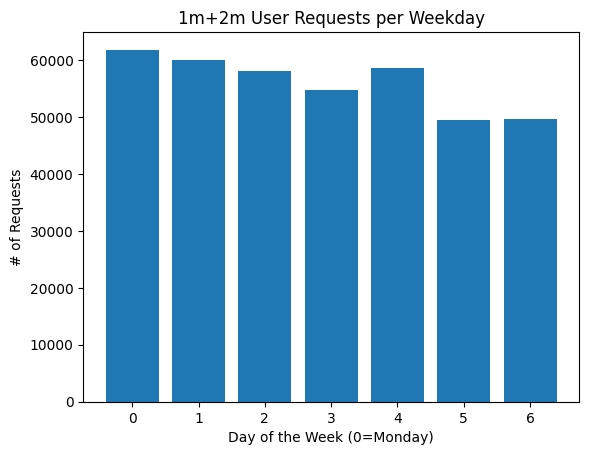

In [26]:
weekday_data = requests["weekday"].value_counts().to_dict()
plt.bar(weekday_data.keys(), weekday_data.values())
plt.title("1m+2m User Requests per Weekday")
plt.xlabel("Day of the Week (0=Monday)")
plt.ylabel("# of Requests")
plt.show()

### Week of the Year

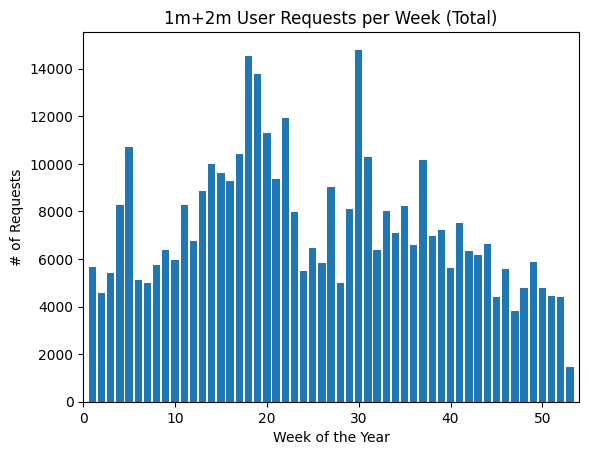

In [27]:
week_data = requests["week"].value_counts().to_dict()
plt.bar(week_data.keys(), week_data.values())
plt.title("1m+2m User Requests per Week (Total)")
plt.xlabel("Week of the Year")
plt.ylabel("# of Requests")
plt.xlim([0, 54])
plt.show()

#### 2020

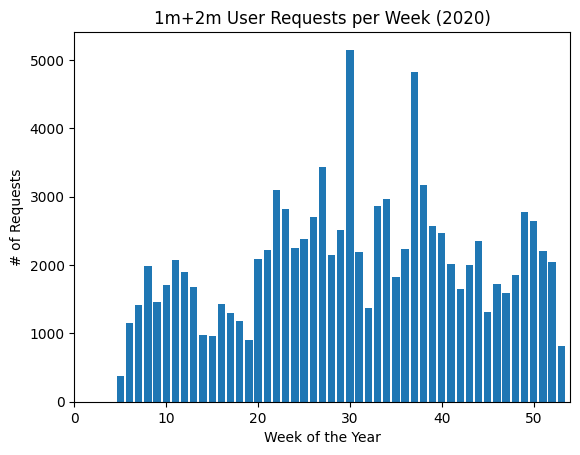

In [28]:
week_data_2020 = requests[requests["year"]==2020]["week"].value_counts().to_dict()
plt.bar(week_data_2020.keys(), week_data_2020.values())
plt.title("1m+2m User Requests per Week (2020)")
plt.xlabel("Week of the Year")
plt.ylabel("# of Requests")
plt.xlim([0, 54])
plt.show()

#### 2021

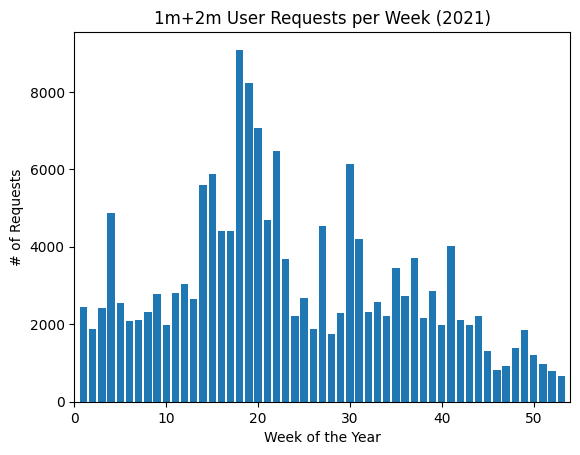

In [29]:
week_data_2021 = requests[requests["year"]==2021]["week"].value_counts().to_dict()
plt.bar(week_data_2021.keys(), week_data_2021.values())
plt.title("1m+2m User Requests per Week (2021)")
plt.xlabel("Week of the Year")
plt.ylabel("# of Requests")
plt.xlim([0, 54])
plt.show()

#### 2022

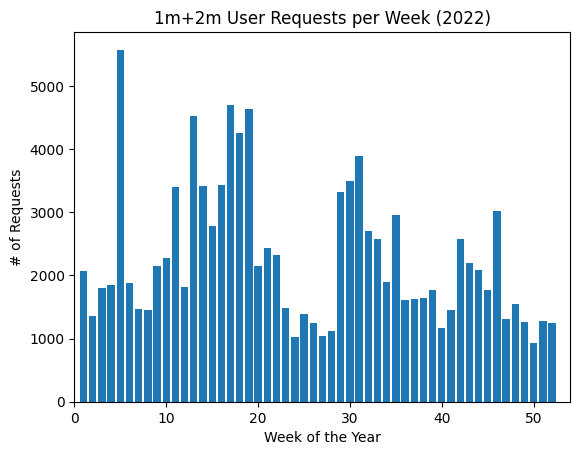

In [30]:
week_data_2022 = requests[requests["year"]==2022]["week"].value_counts().to_dict()
plt.bar(week_data_2022.keys(), week_data_2022.values())
plt.title("1m+2m User Requests per Week (2022)")
plt.xlabel("Week of the Year")
plt.ylabel("# of Requests")
plt.xlim([0, 54])
plt.show()

### Week - Closer Look

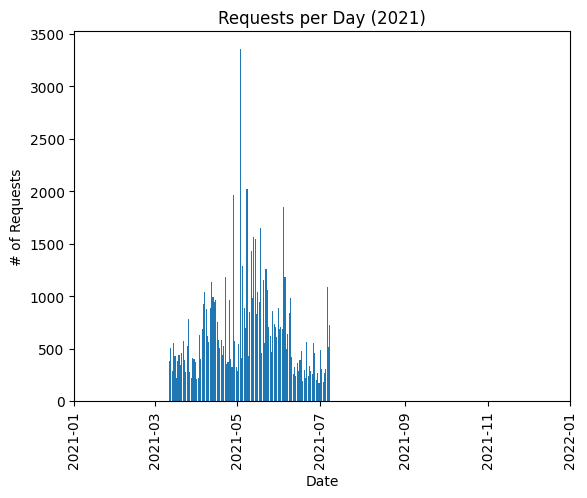

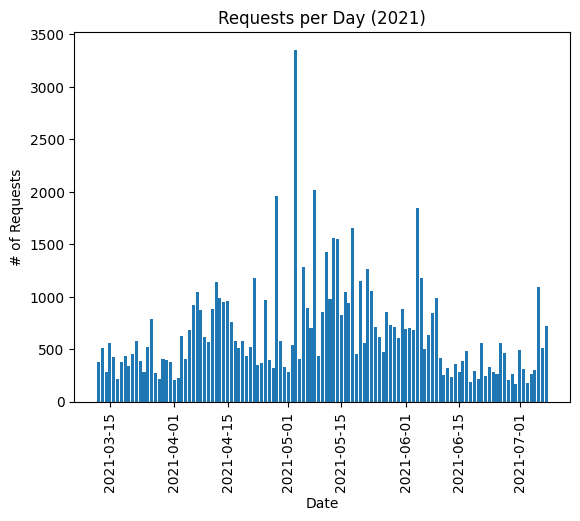

In [46]:
window_start = dt.datetime(2021, 1, 1) + dt.timedelta(days=70)
window_end = dt.datetime(2021, 1, 1) + dt.timedelta(days=189)
requests_peak_2021 = requests[(requests["created"]>window_start)&(requests["created"]<window_end)]
day_peak_2021 = requests_peak_2021["date"].value_counts().to_dict()

plt.bar(day_peak_2021.keys(), day_peak_2021.values())
plt.xlim([dt.datetime(2021, 1, 1), dt.datetime(2022, 1, 1)])
plt.xticks(rotation=90)
plt.title("Requests per Day (2021)")
plt.xlabel("Date")
plt.ylabel("# of Requests")
plt.show()

plt.bar(day_peak_2021.keys(), day_peak_2021.values())
plt.xticks(rotation=90)
plt.title("Requests per Day (2021)")
plt.xlabel("Date")
plt.ylabel("# of Requests")
plt.show()

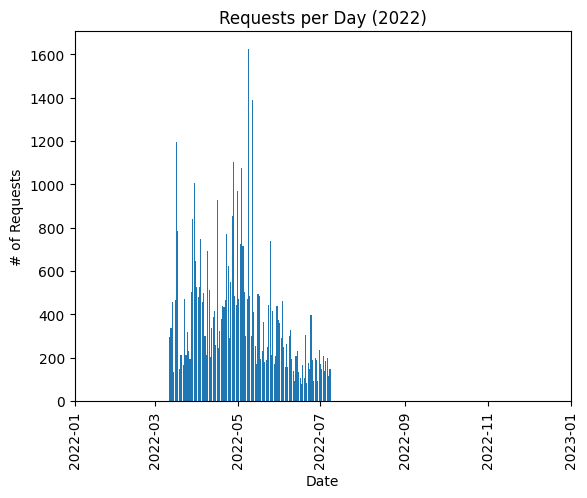

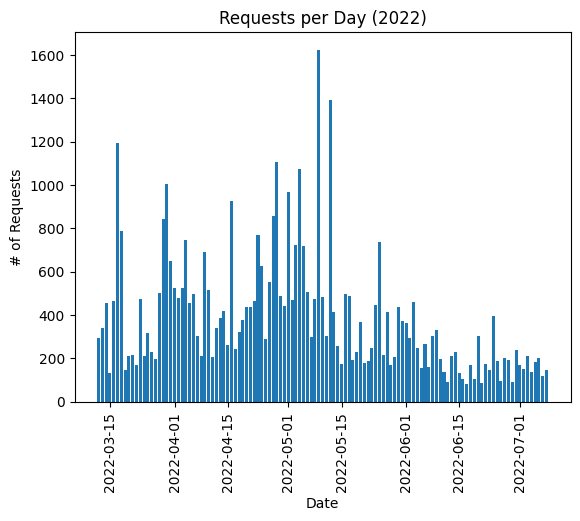

In [47]:
window_start = dt.datetime(2022, 1, 1) + dt.timedelta(days=70)
window_end = dt.datetime(2022, 1, 1) + dt.timedelta(days=189)
requests_peak_2022 = requests[(requests["created"]>window_start)&(requests["created"]<window_end)]
day_peak_2022 = requests_peak_2022["date"].value_counts().to_dict()

plt.bar(day_peak_2022.keys(), day_peak_2022.values())
plt.xlim([dt.datetime(2022, 1, 1), dt.datetime(2023, 1, 1)])
plt.xticks(rotation=90)
plt.title("Requests per Day (2022)")
plt.xlabel("Date")
plt.ylabel("# of Requests")
plt.show()

plt.bar(day_peak_2022.keys(), day_peak_2022.values())
plt.xticks(rotation=90)
plt.title("Requests per Day (2022)")
plt.xlabel("Date")
plt.ylabel("# of Requests")
plt.show()

## By Date

(array([18262., 18383., 18506., 18628., 18748., 18871., 18993., 19113.,
        19236., 19358.]),
 [Text(18262.0, 0, '2020-01'),
  Text(18383.0, 0, '2020-05'),
  Text(18506.0, 0, '2020-09'),
  Text(18628.0, 0, '2021-01'),
  Text(18748.0, 0, '2021-05'),
  Text(18871.0, 0, '2021-09'),
  Text(18993.0, 0, '2022-01'),
  Text(19113.0, 0, '2022-05'),
  Text(19236.0, 0, '2022-09'),
  Text(19358.0, 0, '2023-01')])

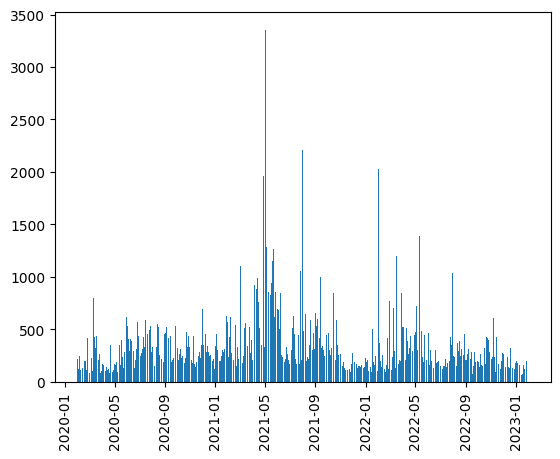

In [34]:
day_data = requests["date"].value_counts().to_dict()
plt.bar(day_data.keys(), day_data.values())
plt.xticks(rotation=90)

### 2020

(array([18322., 18383., 18444., 18506., 18567., 18628.]),
 [Text(18322.0, 0, '2020-03'),
  Text(18383.0, 0, '2020-05'),
  Text(18444.0, 0, '2020-07'),
  Text(18506.0, 0, '2020-09'),
  Text(18567.0, 0, '2020-11'),
  Text(18628.0, 0, '2021-01')])

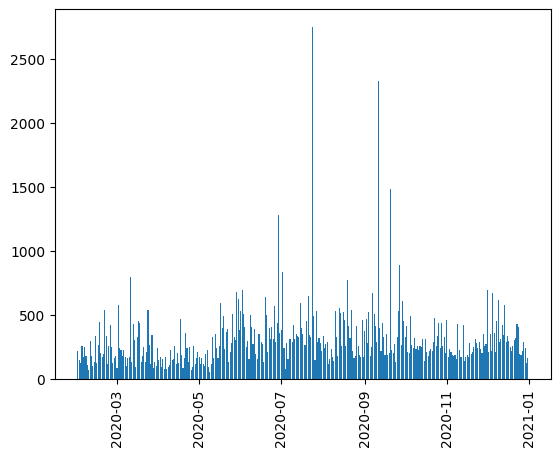

In [35]:
day_data_2020 = requests[requests["year"]==2020]["date"].value_counts().to_dict()
plt.bar(day_data_2020.keys(), day_data_2020.values())
plt.xticks(rotation=90)

### 2021

(array([18628., 18687., 18748., 18809., 18871., 18932., 18993.]),
 [Text(18628.0, 0, '2021-01'),
  Text(18687.0, 0, '2021-03'),
  Text(18748.0, 0, '2021-05'),
  Text(18809.0, 0, '2021-07'),
  Text(18871.0, 0, '2021-09'),
  Text(18932.0, 0, '2021-11'),
  Text(18993.0, 0, '2022-01')])

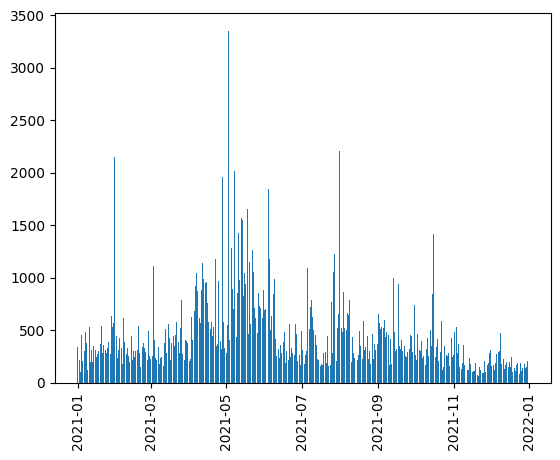

In [36]:
day_data_2021 = requests[requests["year"]==2021]["date"].value_counts().to_dict()
plt.bar(day_data_2021.keys(), day_data_2021.values())
plt.xticks(rotation=90)

### 2022

(array([18993., 19052., 19113., 19174., 19236., 19297., 19358.]),
 [Text(18993.0, 0, '2022-01'),
  Text(19052.0, 0, '2022-03'),
  Text(19113.0, 0, '2022-05'),
  Text(19174.0, 0, '2022-07'),
  Text(19236.0, 0, '2022-09'),
  Text(19297.0, 0, '2022-11'),
  Text(19358.0, 0, '2023-01')])

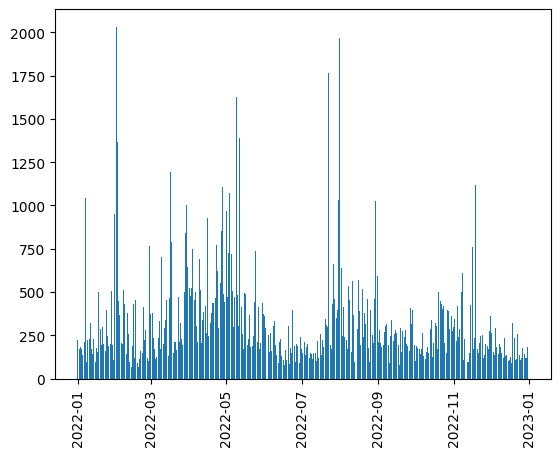

In [37]:
day_data_2022 = requests[requests["year"]==2022]["date"].value_counts().to_dict()
plt.bar(day_data_2022.keys(), day_data_2022.values())
plt.xticks(rotation=90)

## By Date - Calibration

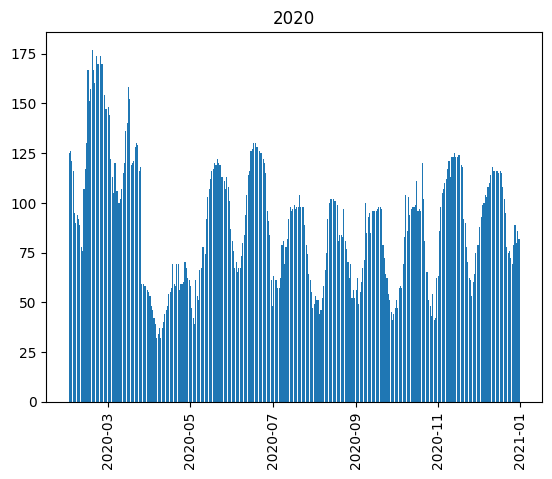

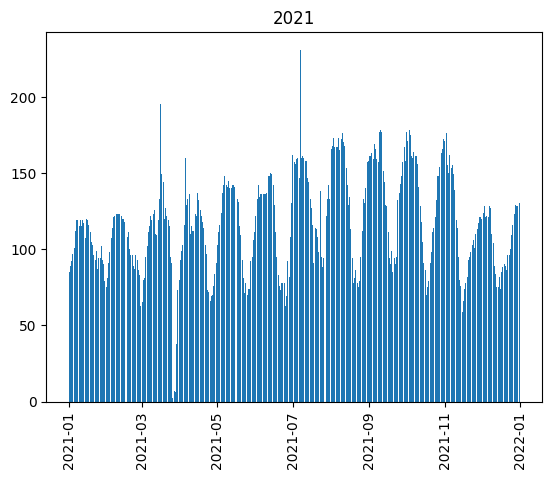

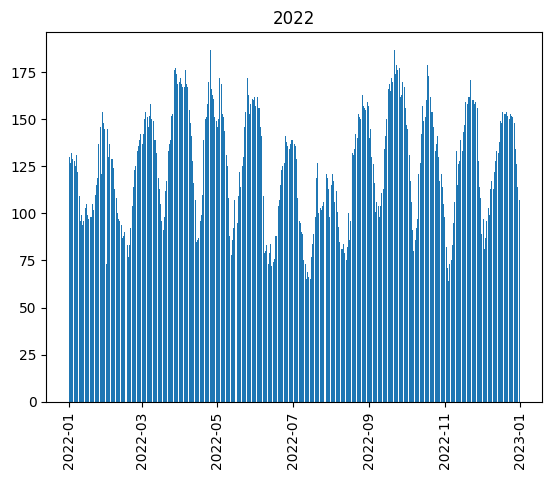

In [39]:
for year in [2020, 2021, 2022]:
    calib_day_data = calibrations[calibrations["year"]==year]["date"].value_counts().to_dict()
    plt.bar(calib_day_data.keys(), calib_day_data.values())
    plt.xticks(rotation=90)
    plt.title(str(year))
    plt.show()

## Semester

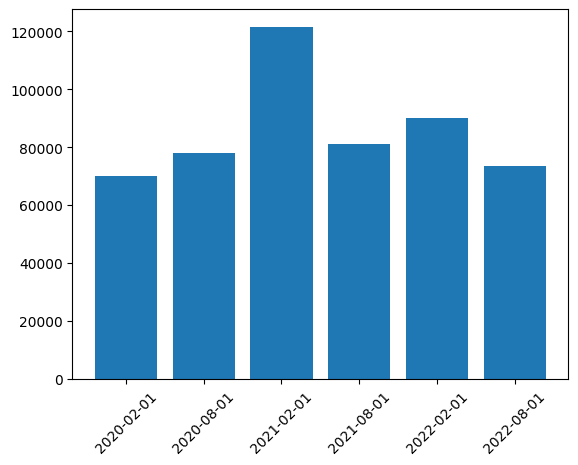

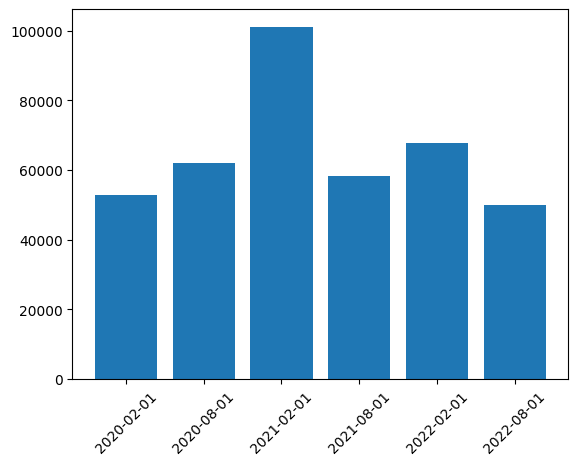

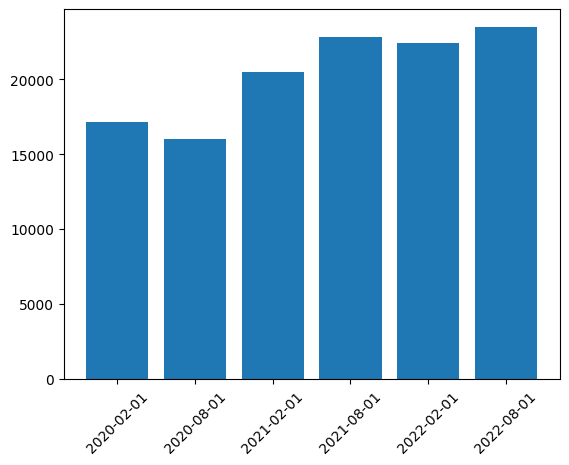

In [67]:
for df in [valid_12, requests, calibrations]:
    semester_data = df["semester_start"].astype(str).value_counts().to_dict()
    x = []
    y = []
    for item in sorted(semester_data.items(), key=lambda x: x[0]):
        x.append(item[0])
        y.append(item[1])
    plt.bar(x, y)
    plt.xticks(rotation=45)
    plt.show()

# plt.bar(semester_data.keys(), semester_data.values())

## Semester Position

<BarContainer object of 184 artists>

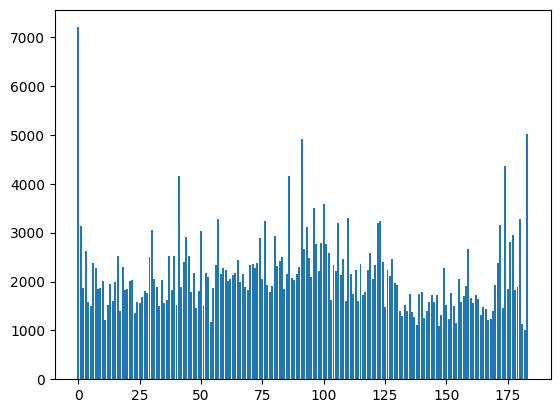

In [50]:
semester_position = requests["semester_position"].value_counts().to_dict()

plt.bar(semester_position.keys(), semester_position.values())



# # Do we need to normalise these by the number of requests made that semester?
# sns.barplot(sdf["semester_position"].value_counts().sort_index())

## 